# Dataset sintetico y EDA v2

Cuaderno de análisis exploratorio del dataset sintético actual tras la migración a etiquetas temporales v2.

Qué revisa:
- balance por serie (`target_global`) y por registro temporal (`target`)
- fases temporales reales dentro de cada secuencia
- trayectorias representativas de `sano`, `insectos` y `moho_critico`
- evolución agregada de CO2, temperatura y humedades
- separabilidad básica entre clases temporales


In [2]:
from pathlib import Path
import sys
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("ggplot")
pd.set_option("display.max_columns", 100)

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "config" / "config.yaml").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_processing.preprocess import build_sequence_feature_frame, build_sliding_windows

dataset = pd.read_csv(ROOT / "data" / "raw" / "dataset_infestacion_cereales_sintetico.csv")
dataset["timestamp"] = pd.to_datetime(dataset["timestamp"])
with open(ROOT / "config" / "config.yaml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

LABEL_NAMES = {0: "sano", 1: "insectos", 2: "moho_critico"}
dataset["target_name"] = dataset["target"].map(LABEL_NAMES)
if "target_global" in dataset.columns:
    dataset["target_global_name"] = dataset["target_global"].map(LABEL_NAMES)
else:
    dataset["target_global"] = dataset["target"]
    dataset["target_global_name"] = dataset["target_name"]

print(f"Filas: {len(dataset):,}")
print(f"Series: {dataset['sample_id'].nunique():,}")
print(f"Columnas: {list(dataset.columns)}")
display(dataset.head())


Filas: 144,000
Series: 300
Columnas: ['sample_id', 'timestamp', 'step_idx', 'co2_ppm', 'temp_c', 'ambient_rh_pct', 'humidity_grain_pct', 'target', 'lag_hours', 'target_global', 'phase_name', 'healthy_until_step', 'transition_to_insect_end_step', 'transition_to_moho_end_step', 'dataset_version', 'config_hash', 'target_name', 'target_global_name']


,sample_id,timestamp,step_idx,co2_ppm,temp_c,ambient_rh_pct,humidity_grain_pct,target,lag_hours,target_global,phase_name,healthy_until_step,transition_to_insect_end_step,transition_to_moho_end_step,dataset_version,config_hash,target_name,target_global_name
0,S_0_0000,2026-01-01 00:00:00,0,407.539567,17.482924,50.205255,12.648710,0,86,0,sano,68,NaN,NaN,synth_v_9858f137e755,9858f137e755,sano,sano
1,S_0_0000,2026-01-01 01:00:00,1,403.591294,17.027913,49.966017,12.705193,0,86,0,sano,68,NaN,NaN,synth_v_9858f137e755,9858f137e755,sano,sano
2,S_0_0000,2026-01-01 02:00:00,2,402.807321,16.659834,52.400092,12.656834,0,86,0,sano,68,NaN,NaN,synth_v_9858f137e755,9858f137e755,sano,sano
3,S_0_0000,2026-01-01 03:00:00,3,423.782387,16.442272,51.870873,12.617449,0,86,0,sano,68,NaN,NaN,synth_v_9858f137e755,9858f137e755,sano,sano
4,S_0_0000,2026-01-01 04:00:00,4,431.035695,16.354355,51.386627,12.640209,0,86,0,sano,68,NaN,NaN,synth_v_9858f137e755,9858f137e755,sano,sano


Balance por serie y por registro temporal:


,n_series,n_rows,row_share
sano,100,59947,0.416299
insectos,100,47983,0.333215
moho_critico,100,36070,0.250486


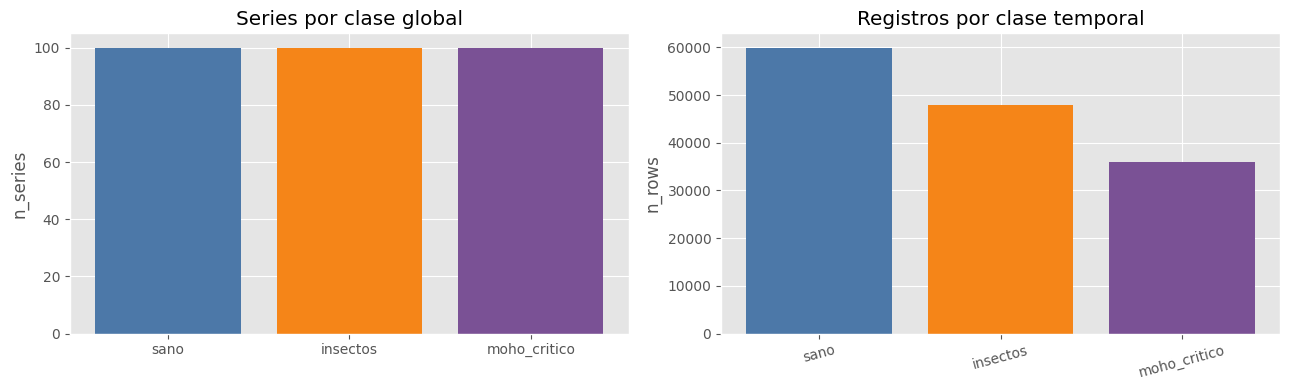

In [3]:
series_balance = (
    dataset.groupby("target_global_name")["sample_id"]
    .nunique()
    .rename("n_series")
    .reindex(["sano", "insectos", "moho_critico"])
)
row_balance = (
    dataset["target_name"]
    .value_counts()
    .rename("n_rows")
    .reindex(["sano", "insectos", "moho_critico"])
)

summary_balance = pd.concat([series_balance, row_balance], axis=1)
summary_balance["row_share"] = summary_balance["n_rows"] / summary_balance["n_rows"].sum()
print("Balance por serie y por registro temporal:")
display(summary_balance)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(summary_balance.index, summary_balance["n_series"], color=["#4C78A8", "#F58518", "#7A5195"])
axes[0].set_title("Series por clase global")
axes[0].set_ylabel("n_series")
axes[1].bar(summary_balance.index, summary_balance["n_rows"], color=["#4C78A8", "#F58518", "#7A5195"])
axes[1].set_title("Registros por clase temporal")
axes[1].set_ylabel("n_rows")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


,sample_id,target_global_name,first_phase,last_phase,temporal_phase_changes,healthy_until_step,transition_to_insect_end_step,transition_to_moho_end_step
0,S_0_0000,sano,sano,sano,0,68,NaN,NaN
1,S_0_0001,sano,sano,sano,0,36,NaN,NaN
2,S_0_0002,sano,sano,sano,0,36,NaN,NaN
3,S_0_0003,sano,sano,sano,0,46,NaN,NaN
4,S_0_0004,sano,sano,sano,0,54,NaN,NaN


C:\Users\Feliciano\AppData\Local\Temp\ipykernel_6888\1949453831.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(values, patch_artist=True, labels=classes)


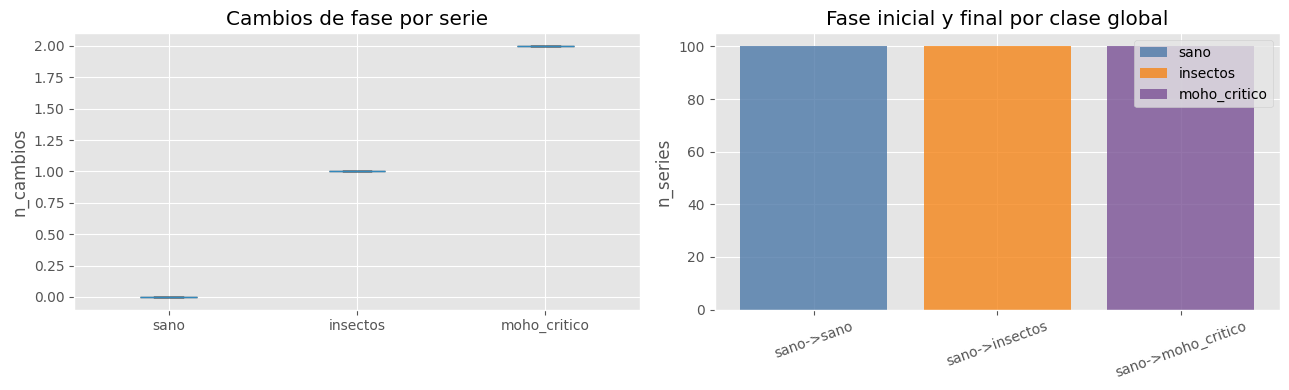

In [4]:
sample_phase = (
    dataset.groupby("sample_id")
    .agg(
        target_global_name=("target_global_name", "first"),
        first_phase=("target_name", "first"),
        last_phase=("target_name", "last"),
        temporal_phase_changes=("target", lambda s: int((s.diff().fillna(0) != 0).sum())),
        healthy_until_step=("healthy_until_step", "first") if "healthy_until_step" in dataset.columns else ("target", "size"),
        transition_to_insect_end_step=("transition_to_insect_end_step", "first") if "transition_to_insect_end_step" in dataset.columns else ("target", "size"),
        transition_to_moho_end_step=("transition_to_moho_end_step", "first") if "transition_to_moho_end_step" in dataset.columns else ("target", "size"),
    )
    .reset_index()
)
display(sample_phase.head())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
classes = ["sano", "insectos", "moho_critico"]
values = [sample_phase.loc[sample_phase["target_global_name"] == cls, "temporal_phase_changes"].values for cls in classes]
bp = axes[0].boxplot(values, patch_artist=True, labels=classes)
for patch, color in zip(bp["boxes"], ["#4C78A8", "#F58518", "#7A5195"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
axes[0].set_title("Cambios de fase por serie")
axes[0].set_ylabel("n_cambios")

start_end = (
    sample_phase.groupby(["target_global_name", "first_phase", "last_phase"])
    .size()
    .rename("n_series")
    .reset_index()
)
for class_name, color in zip(classes, ["#4C78A8", "#F58518", "#7A5195"]):
    subset = start_end[start_end["target_global_name"] == class_name]
    axes[1].bar(
        [f"{row.first_phase}->{row.last_phase}" for row in subset.itertuples()],
        subset["n_series"],
        alpha=0.8,
        label=class_name,
        color=color,
    )
axes[1].set_title("Fase inicial y final por clase global")
axes[1].set_ylabel("n_series")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()
plt.tight_layout()
plt.show()


In [5]:
transition_cols = [
    c for c in [
        "healthy_until_step",
        "transition_to_insect_end_step",
        "transition_to_moho_end_step",
        "phase_name",
    ]
    if c in dataset.columns
]
if transition_cols:
    transition_summary = (
        dataset.groupby("sample_id")[["target_global"] + [c for c in transition_cols if c != "phase_name"]]
        .first()
        .assign(target_global_name=lambda x: x["target_global"].map(LABEL_NAMES))
    )
    print("Resumen de transiciones por serie:")
    display(
        transition_summary.groupby("target_global_name")
        .agg(["min", "median", "max"])
        .round(2)
    )


Resumen de transiciones por serie:


target_global            healthy_until_step             \
                             min median max                min median max   
target_global_name                                                          
insectos                       1    1.0   1                 36   36.0  70   
moho_critico                   2    2.0   2                 36   36.0  69   
sano                           0    0.0   0                 36   36.0  74   

                   transition_to_insect_end_step                \
                                             min median    max   
target_global_name                                               
insectos                                    85.0  109.0  141.0   
moho_critico                                66.0   78.5  124.0   
sano                                         NaN    NaN    NaN   

                   transition_to_moho_end_step                
                                           min median    max  
target_global_name                                            
insectos                                   NaN    NaN    NaN  
moho_critico                              96.0  118.0  174.0  
sano                                       NaN    NaN    NaN

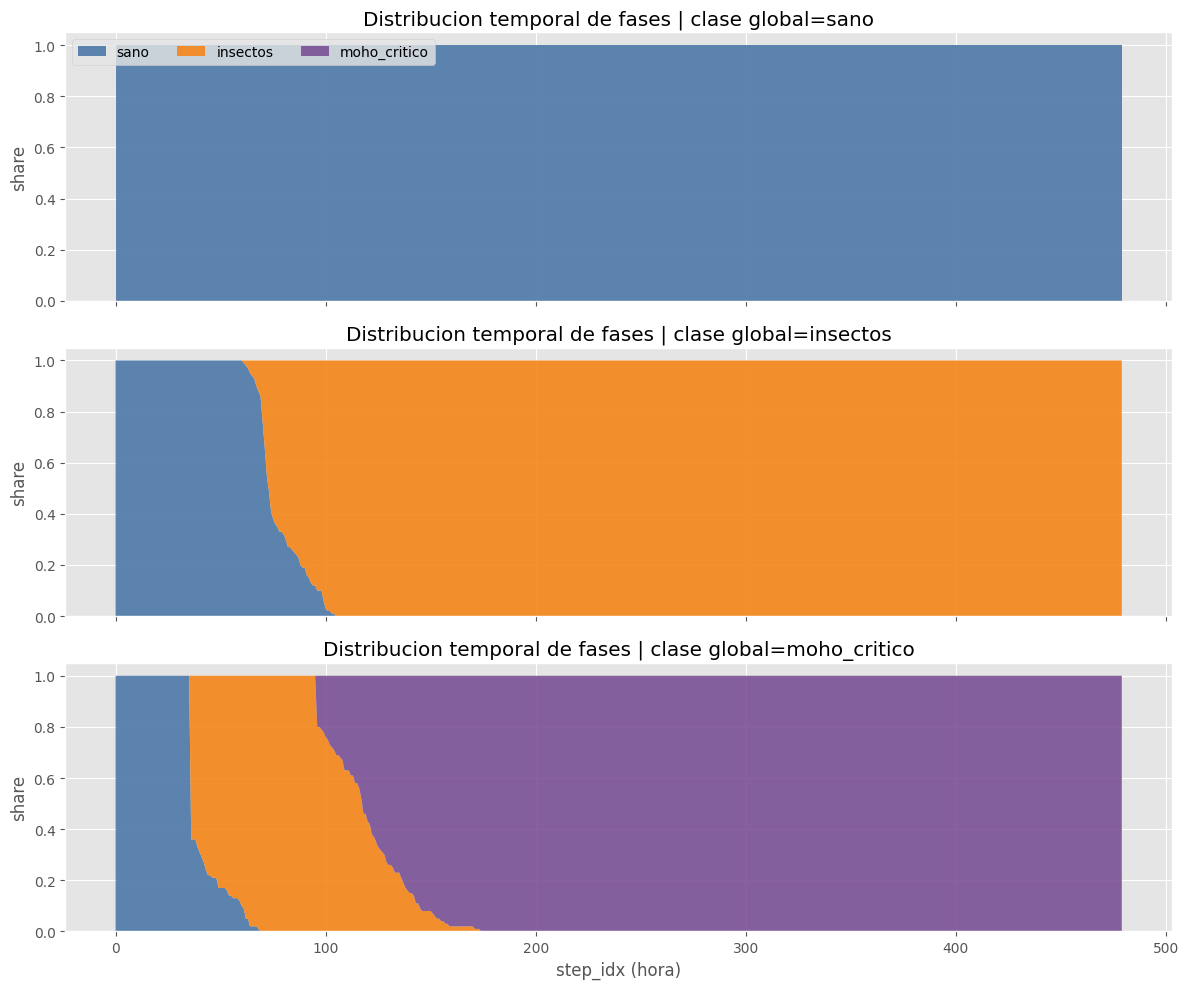

In [6]:
phase_share = (
    dataset.groupby(["target_global_name", "step_idx", "target_name"])
    .size()
    .rename("count")
    .reset_index()
)
phase_share["share"] = phase_share.groupby(["target_global_name", "step_idx"])["count"].transform(lambda x: x / x.sum())

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
classes = ["sano", "insectos", "moho_critico"]
phase_order = ["sano", "insectos", "moho_critico"]
colors = {"sano": "#4C78A8", "insectos": "#F58518", "moho_critico": "#7A5195"}

for ax, class_name in zip(axes, classes):
    subset = phase_share[phase_share["target_global_name"] == class_name]
    pivot = (
        subset.pivot(index="step_idx", columns="target_name", values="share")
        .reindex(columns=phase_order)
        .fillna(0.0)
    )
    ax.stackplot(
        pivot.index,
        *[pivot[col].values for col in phase_order],
        labels=phase_order,
        colors=[colors[col] for col in phase_order],
        alpha=0.9,
    )
    ax.set_title(f"Distribucion temporal de fases | clase global={class_name}")
    ax.set_ylabel("share")

axes[-1].set_xlabel("step_idx (hora)")
axes[0].legend(loc="upper left", ncol=3)
plt.tight_layout()
plt.show()


,sample_id,target_global_name,phase_name,duration_hours
0,S_0_0000,sano,sano,480
1,S_0_0001,sano,sano,480
2,S_0_0002,sano,sano,480
3,S_0_0003,sano,sano,480
4,S_0_0004,sano,sano,480


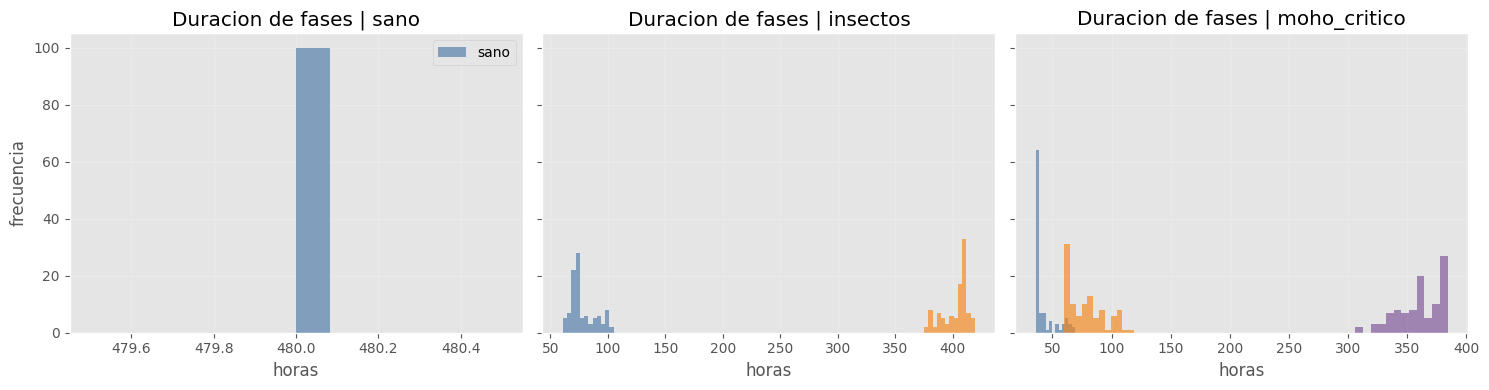

In [7]:
phase_lengths = []
for sample_id, sample in dataset.groupby("sample_id", sort=False):
    sample = sample.sort_values("timestamp")
    target_global_name = sample["target_global_name"].iloc[0]
    phase_series = sample["target_name"].to_numpy()
    step_series = sample["step_idx"].to_numpy()
    change_points = np.r_[0, np.where(phase_series[1:] != phase_series[:-1])[0] + 1, len(sample)]
    for start, end in zip(change_points[:-1], change_points[1:]):
        phase_lengths.append(
            {
                "sample_id": sample_id,
                "target_global_name": target_global_name,
                "phase_name": phase_series[start],
                "duration_hours": int(step_series[end - 1] - step_series[start] + 1),
            }
        )

phase_lengths = pd.DataFrame(phase_lengths)
display(phase_lengths.head())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, class_name in zip(axes, ["sano", "insectos", "moho_critico"]):
    subset = phase_lengths[phase_lengths["target_global_name"] == class_name]
    for phase_name, color in [("sano", "#4C78A8"), ("insectos", "#F58518"), ("moho_critico", "#7A5195")]:
        values = subset.loc[subset["phase_name"] == phase_name, "duration_hours"]
        if len(values):
            ax.hist(values, bins=12, alpha=0.65, label=phase_name, color=color)
    ax.set_title(f"Duracion de fases | {class_name}")
    ax.set_xlabel("horas")
    ax.grid(True, alpha=0.2)
axes[0].set_ylabel("frecuencia")
axes[0].legend()
plt.tight_layout()
plt.show()


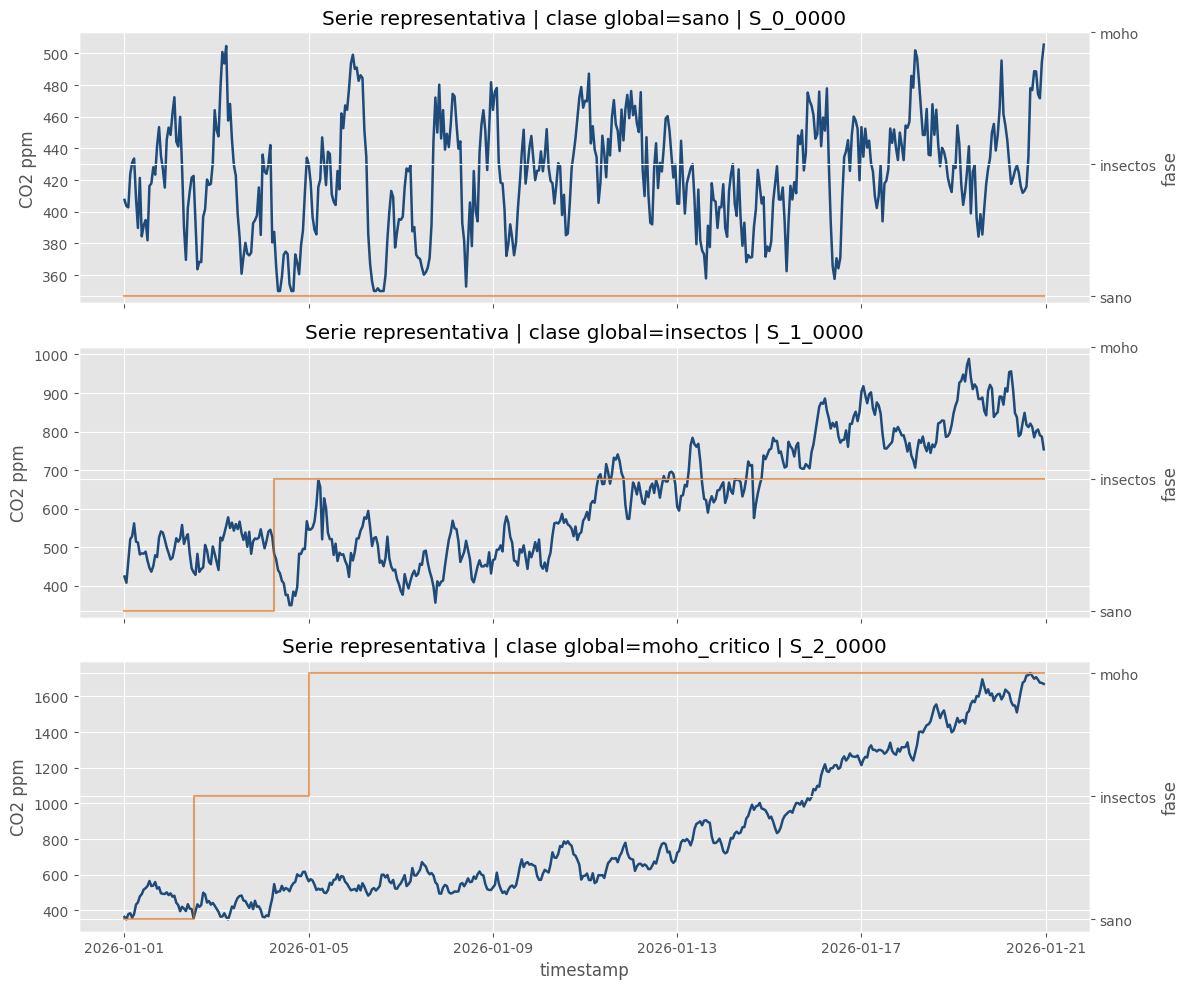

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, class_id in zip(axes, [0, 1, 2]):
    sample_id = (
        dataset.loc[dataset["target_global"] == class_id, "sample_id"]
        .drop_duplicates()
        .iloc[0]
    )
    sample = dataset.loc[dataset["sample_id"] == sample_id].copy()
    sample["phase_numeric"] = sample["target"]

    ax.plot(sample["timestamp"], sample["co2_ppm"], color="#1f4b7a", linewidth=1.8, label="CO2")
    ax2 = ax.twinx()
    ax2.step(sample["timestamp"], sample["phase_numeric"], where="post", color="#d95f02", alpha=0.55, label="fase temporal")
    ax.set_title(f"Serie representativa | clase global={LABEL_NAMES[class_id]} | {sample_id}")
    ax.set_ylabel("CO2 ppm")
    ax2.set_ylabel("fase")
    ax2.set_yticks([0, 1, 2], labels=["sano", "insectos", "moho"])

axes[-1].set_xlabel("timestamp")
plt.tight_layout()
plt.show()


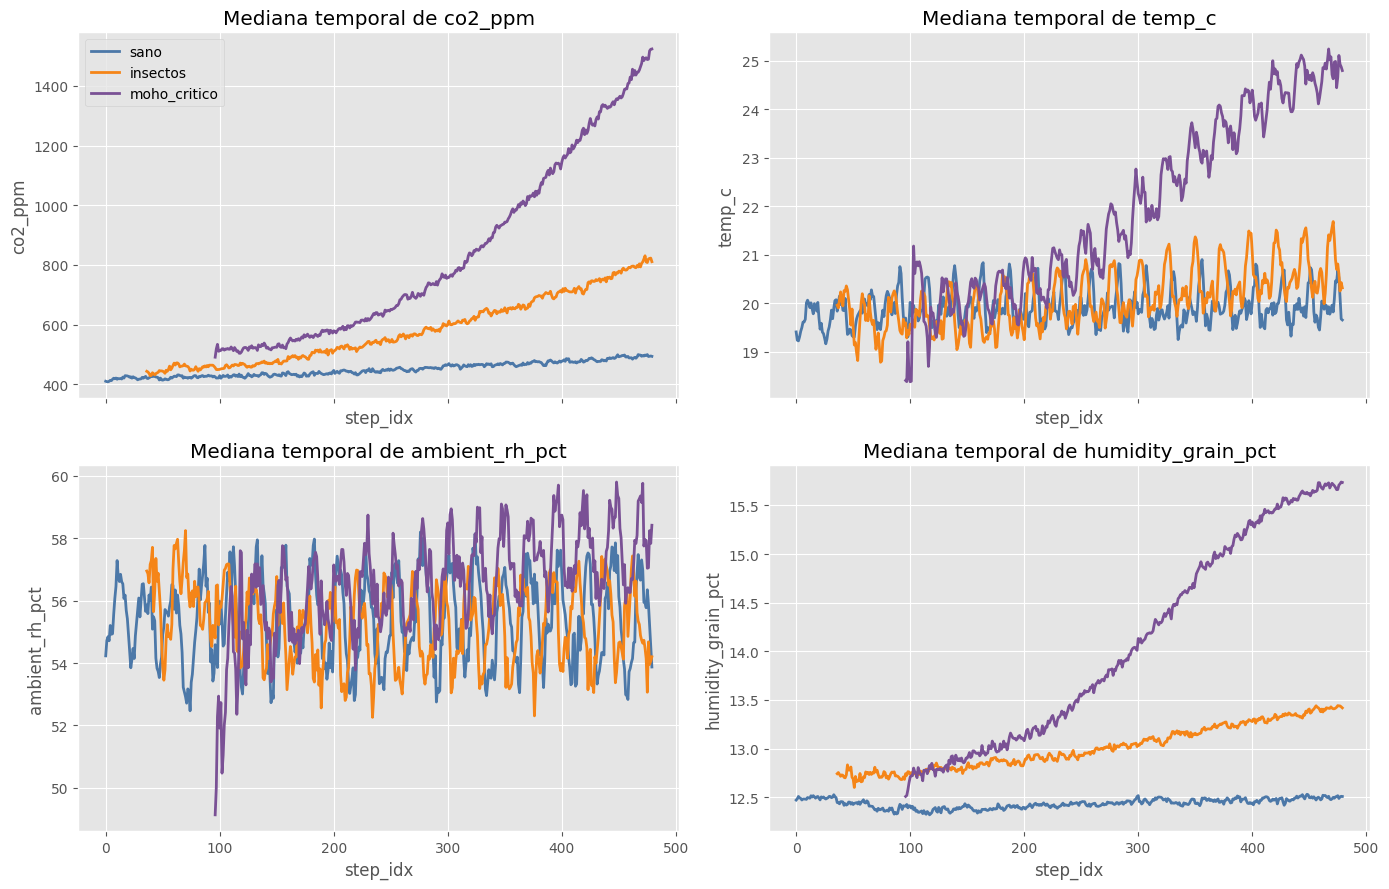

In [9]:
metric_cols = ["co2_ppm", "temp_c", "ambient_rh_pct", "humidity_grain_pct"]
step_profile = (
    dataset.groupby(["target_name", "step_idx"])[metric_cols]
    .median()
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.ravel()
colors = {"sano": "#4C78A8", "insectos": "#F58518", "moho_critico": "#7A5195"}
for ax, col in zip(axes, metric_cols):
    for class_name in ["sano", "insectos", "moho_critico"]:
        d = step_profile[step_profile["target_name"] == class_name]
        ax.plot(d["step_idx"], d[col], label=class_name, color=colors[class_name], linewidth=2)
    ax.set_title(f"Mediana temporal de {col}")
    ax.set_xlabel("step_idx")
    ax.set_ylabel(col)
axes[0].legend()
plt.tight_layout()
plt.show()


Numero total de ventanas: 11,100


,n_windows,share
sano,4038,0.363784
insectos,4019,0.362072
moho_critico,3043,0.274144


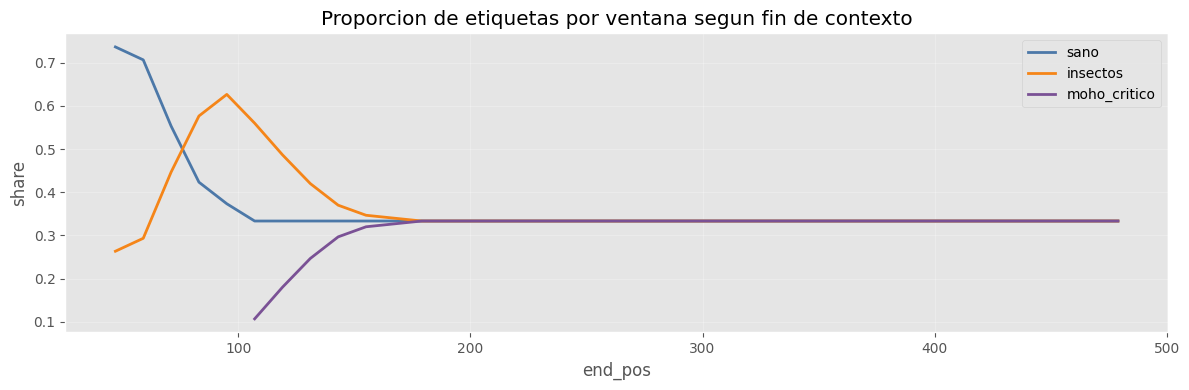

In [10]:
seq_df, feature_columns = build_sequence_feature_frame(dataset.copy(), cfg, require_target=True)
window_payload = build_sliding_windows(seq_df, cfg, feature_columns=feature_columns)

y_seq = pd.Series(window_payload["y_seq"]).map(LABEL_NAMES)
window_balance = (
    y_seq.value_counts()
    .reindex(["sano", "insectos", "moho_critico"])
    .fillna(0)
    .rename("n_windows")
)

print(f"Numero total de ventanas: {len(y_seq):,}")
display(window_balance.to_frame().assign(share=lambda x: x["n_windows"] / x["n_windows"].sum()))

meta = window_payload["window_meta"].copy()
meta["target_name"] = pd.Series(window_payload["y_seq"]).map(LABEL_NAMES).to_numpy()
meta["timestamp_end"] = pd.to_datetime(meta["timestamp_end"])

by_window_end = (
    meta.groupby(["end_pos", "target_name"])
    .size()
    .rename("count")
    .reset_index()
)
by_window_end["share"] = by_window_end.groupby("end_pos")["count"].transform(lambda x: x / x.sum())

fig, ax = plt.subplots(figsize=(12, 4))
for class_name, color in [("sano", "#4C78A8"), ("insectos", "#F58518"), ("moho_critico", "#7A5195")]:
    subset = by_window_end[by_window_end["target_name"] == class_name]
    ax.plot(subset["end_pos"], subset["share"], label=class_name, color=color, linewidth=2)

ax.set_title("Proporcion de etiquetas por ventana segun fin de contexto")
ax.set_xlabel("end_pos")
ax.set_ylabel("share")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

,sample_id,target_global,co2_mean,co2_std,temp_mean,rh_mean,grain_mean,temporal_phase_changes
0,S_0_0000,sano,423.038390,34.882427,18.469052,54.747235,12.750224,0
1,S_0_0001,sano,476.272250,45.324707,28.932644,55.265547,12.924040,0
2,S_0_0002,sano,474.880639,48.561817,20.739661,53.145710,12.068310,0
3,S_0_0003,sano,435.220543,37.153884,18.078219,46.254169,11.925486,0
4,S_0_0004,sano,452.359597,50.701004,14.642418,35.755614,11.852629,0


C:\Users\Feliciano\AppData\Local\Temp\ipykernel_6888\2243522775.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, patch_artist=True, labels=classes)
C:\Users\Feliciano\AppData\Local\Temp\ipykernel_6888\2243522775.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, patch_artist=True, labels=classes)
C:\Users\Feliciano\AppData\Local\Temp\ipykernel_6888\2243522775.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, patch_artist=True, labels=classes)
C:\Users\Feliciano\AppData\Local\Temp\ipykernel_6888\2243522775.py:27: MatplotlibDeprecationWarni

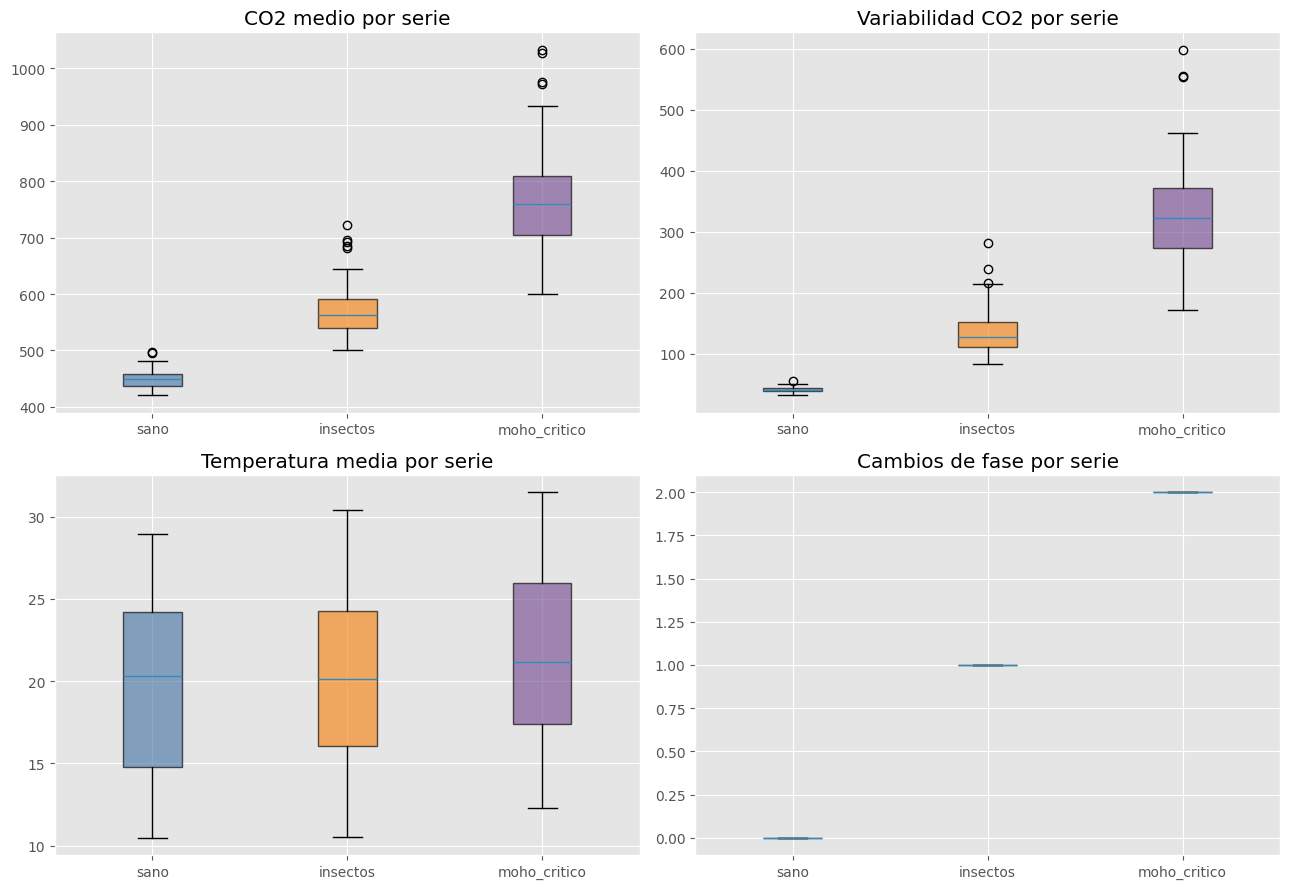

In [11]:
sample_stats = (
    dataset.groupby("sample_id")
    .agg(
        target_global=("target_global_name", "first"),
        co2_mean=("co2_ppm", "mean"),
        co2_std=("co2_ppm", "std"),
        temp_mean=("temp_c", "mean"),
        rh_mean=("ambient_rh_pct", "mean"),
        grain_mean=("humidity_grain_pct", "mean"),
        temporal_phase_changes=("target", lambda s: int((s.diff().fillna(0) != 0).sum())),
    )
    .reset_index()
)
display(sample_stats.head())

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
box_specs = [
    ("co2_mean", "CO2 medio por serie", axes[0, 0]),
    ("co2_std", "Variabilidad CO2 por serie", axes[0, 1]),
    ("temp_mean", "Temperatura media por serie", axes[1, 0]),
    ("temporal_phase_changes", "Cambios de fase por serie", axes[1, 1]),
]
classes = ["sano", "insectos", "moho_critico"]
colors = ["#4C78A8", "#F58518", "#7A5195"]
for metric, title, ax in box_specs:
    values = [sample_stats.loc[sample_stats["target_global"] == cls, metric].dropna().values for cls in classes]
    bp = ax.boxplot(values, patch_artist=True, labels=classes)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    ax.set_title(title)
plt.tight_layout()
plt.show()


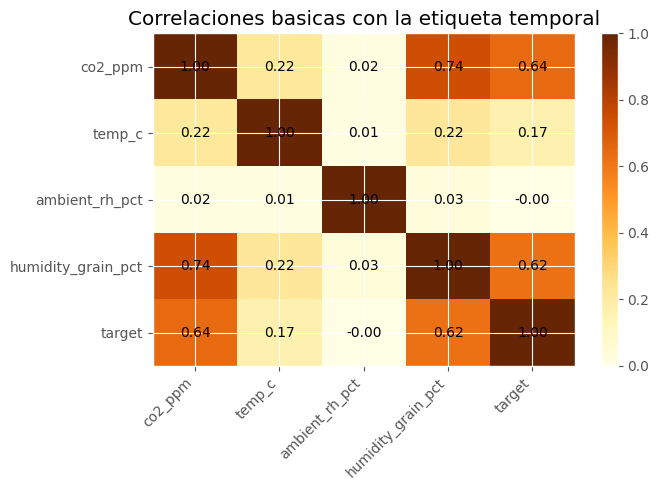

In [12]:
corr = dataset[["co2_ppm", "temp_c", "ambient_rh_pct", "humidity_grain_pct", "target"]].corr(numeric_only=True)
plt.figure(figsize=(7, 5))
plt.imshow(corr, cmap="YlOrBr", aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")
plt.colorbar()
plt.title("Correlaciones basicas con la etiqueta temporal")
plt.tight_layout()
plt.show()
